## Notebook to process and plot results from scripts

Set `RESULT_FILE` to any JSON result beneath `scripts/output` (or to an absolute path)

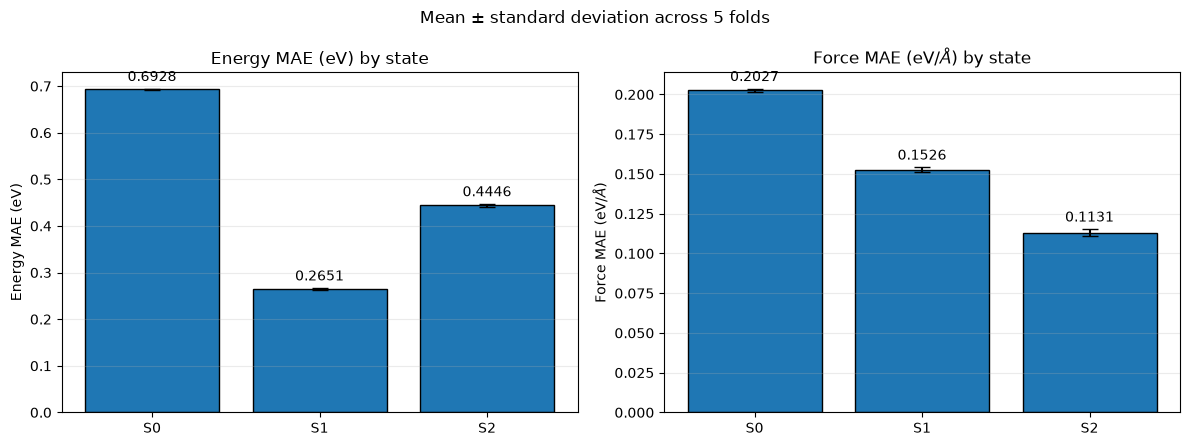

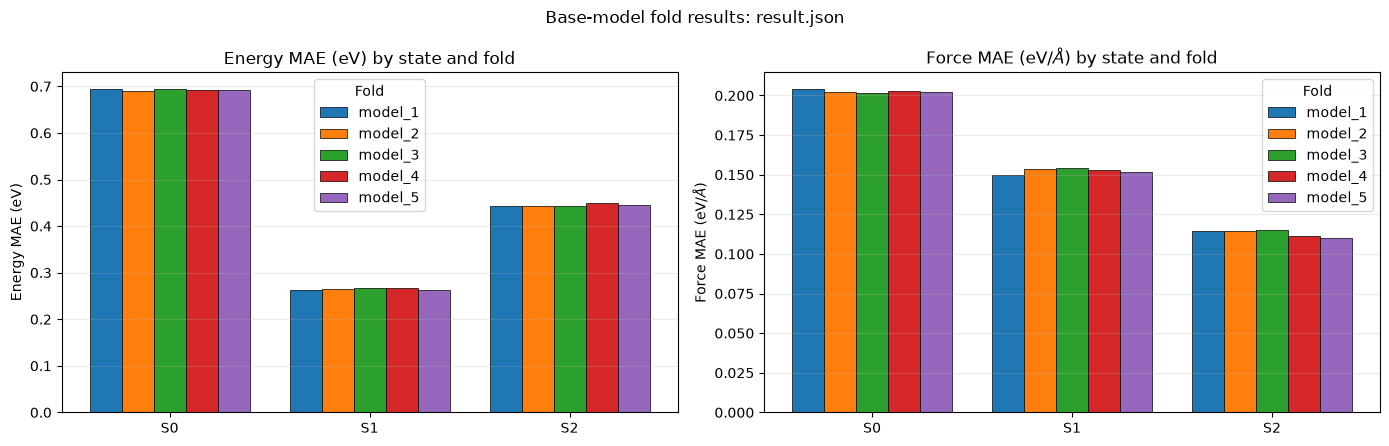

In [6]:
# Set this to another result JSON (relative to scripts/output) or an absolute path.
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_FILE = Path("run_70/result.json")

# Resolve the result file from either the repository root or notebooks/.
if RESULT_FILE.is_absolute():
    result_candidates = [RESULT_FILE]
else:
    result_candidates = [
        Path("scripts/output") / RESULT_FILE,
        Path("../scripts/output") / RESULT_FILE,
    ]
result_path = next((path.resolve() for path in result_candidates if path.is_file()), None)
if result_path is None:
    raise FileNotFoundError(f"Could not find result file: {RESULT_FILE}")

with result_path.open() as file:
    result = json.load(file)

# Only use the base-model folds, not full or transfer models.
folds = result["cross_validation_training"]["base_models"]["folds"]
if not folds:
    raise ValueError("No base-model folds found in the selected result file.")

def natural_sort_key(value):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", value)]

records = []
for fold_name in sorted(folds, key=natural_sort_key):
    metrics = folds[fold_name]["metrics"]
    for state, value in metrics["energy_mae_by_state_ev"].items():
        records.append({"fold": fold_name, "state": state, "metric": "Energy MAE (eV)", "mae": value})
    for state, value in metrics["force_mae_by_state_ev_per_ang"].items():
        records.append({"fold": fold_name, "state": state, "metric": r"Force MAE (eV/$\AA$)", "mae": value})

state_mae = pd.DataFrame(records)
states = sorted(state_mae["state"].unique(), key=natural_sort_key)
fold_order = sorted(state_mae["fold"].unique(), key=natural_sort_key)

# Mean ± sample standard deviation across the five folds, one chart per metric.
summary = state_mae.groupby(["metric", "state"])["mae"].agg(["mean", "std"]).reindex(
    pd.MultiIndex.from_product([["Energy MAE (eV)", r"Force MAE (eV/$\AA$)"], states], names=["metric", "state"])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, metric in zip(axes, ["Energy MAE (eV)", r"Force MAE (eV/$\AA$)"]):
    values = summary.loc[metric]
    bars = ax.bar(states, values["mean"], yerr=values["std"].fillna(0), capsize=6, edgecolor="black")
    ax.set_title(metric + " by state")
    ax.set_ylabel(metric)
    ax.bar_label(bars, fmt="%.4g", padding=3)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle(f"Mean ± standard deviation across {len(fold_order)} folds")
fig.tight_layout()
plt.show()

# Fold-level view: each fold is a separate bar (no error bars).
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
x = np.arange(len(states))
width = 0.8 / len(fold_order)
for ax, metric in zip(axes, ["Energy MAE (eV)", r"Force MAE (eV/$\AA$)"]):
    metric_data = state_mae[state_mae["metric"] == metric]
    for index, fold_name in enumerate(fold_order):
        values = metric_data[metric_data["fold"] == fold_name].set_index("state").loc[states, "mae"]
        ax.bar(x + (index - (len(fold_order) - 1) / 2) * width, values, width, label=fold_name, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x, states)
    ax.set_title(metric + " by state and fold")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.25)
    
    ax.legend(title="Fold")
fig.suptitle(f"Base-model fold results: {result_path.name}")
fig.tight_layout()
plt.show()


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

RESULT_FILE = Path("run_69/result.json")

result_path = next(
    (path / RESULT_FILE for path in (Path("scripts/output"), Path("../scripts/output")) if (path / RESULT_FILE).is_file()),
    None,
)
if result_path is None:
    raise FileNotFoundError(f"Could not find result file: {RESULT_FILE}")

with result_path.open() as file:
    metrics = json.load(file)["metrics"]["base_model"]

energy_mae_by_state = metrics["energy_mae_by_state_ev"]
force_mae_by_state = metrics["force_mae_by_state_ev_per_ang"]
states = list(energy_mae_by_state)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title, ylabel, color in (
    (axes[0], energy_mae_by_state, "Energy MAE by state", "Energy MAE (eV)", "#4C78A8"),
    (axes[1], force_mae_by_state, r"Force MAE by state", r"Force MAE (eV/$\AA$)", "#F58518"),
):
    bars = ax.bar(states, [values[state] for state in states], color=color, edgecolor="black")
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Run 21 base model: MAE by state")
fig.tight_layout()
plt.show()


KeyError: 'base_model'

In [2]:
# Re-evaluate every fold on a chosen XYZ test set, then plot the new MAEs.
import gc
import re
import sys
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path("..").resolve()))

from scripts.tester import _evaluate, _import_project_modules, _load_model

# Paths are relative to notebooks/.
RUN_DIRECTORY = Path("../scripts/output/run_36")
TEST_XYZ = Path("../data/A02_propene_offgrid_SA3-NEVPT2_22_molcas.xyz")
print("here")
# These must match the model's training setup; update them for another run.
R_MAX = 5.0
BATCH_SIZE = 10
ENERGY_KEY = "REF_energy"
FORCES_KEY = "REF_forces"
E0S = {"C": -1035.5115207879423, "H": -15.712048126191444}

def natural_sort_key(value):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", str(value))]

run_dir = RUN_DIRECTORY.resolve()
test_path = TEST_XYZ.resolve()

model_paths = sorted(run_dir.glob("full_model_fold_*.pt"), key=lambda path: natural_sort_key(path.stem))
test_atoms = ase.io.read(test_path, index=":")
if not isinstance(test_atoms, list):
    test_atoms = [test_atoms]
modules = _import_project_modules()
AtomDataLoaderBuilder, Tester = modules[1], modules[2]
loader = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key=ENERGY_KEY, forces_key=FORCES_KEY, E0s=E0S
).load(test_atoms, batch_size=BATCH_SIZE, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

records = []
for model_path in model_paths:
    print(f"Evaluating model: {model_path.name}")
    fold_name = "model_" + model_path.stem.rsplit("_", 1)[1]
    model = _load_model(model_path, device)
    metrics = _evaluate(model, loader, Tester(device=device))
    for state, mae in metrics["energy_mae_by_state_ev"].items():
        records.append({"fold": fold_name, "state": state, "metric": "Energy MAE (eV)", "mae": mae})
    for state, mae in metrics["force_mae_by_state_ev_per_ang"].items():
        records.append({"fold": fold_name, "state": state, "metric": r"Force MAE (eV/$\AA$)", "mae": mae})
    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

state_mae = pd.DataFrame(records)
states = sorted(state_mae["state"].unique(), key=natural_sort_key)
fold_order = sorted(state_mae["fold"].unique(), key=natural_sort_key)
metric_order = ["Energy MAE (eV)", r"Force MAE (eV/$\AA$)"]
summary = state_mae.groupby(["metric", "state"])["mae"].agg(["mean", "std"])


here
Evaluating model: full_model_fold_1.pt


KeyboardInterrupt: 

In [9]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_FILE = Path("run_36/result.json")
result_candidates = [
    Path("scripts/output") / RESULT_FILE,
    Path("../scripts/output") / RESULT_FILE,
]
result_path = next((path.resolve() for path in result_candidates if path.is_file()), None)
if result_path is None:
    raise FileNotFoundError(f"Could not find result file: {RESULT_FILE}")

with result_path.open() as file:
    result = json.load(file)

def natural_sort_key(value):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", str(value))]

folds = result["cross_validation_training"]["full_high_fidelity_models"]["folds"]
records = []
for fold_name in sorted(folds, key=natural_sort_key):
    metrics = folds[fold_name]["metrics"]
    for state, mae in metrics["energy_mae_by_state_ev"].items():
        records.append({"fold": fold_name, "state": state, "metric": "Energy MAE (eV)", "mae": mae})
    for state, mae in metrics["force_mae_by_state_ev_per_ang"].items():
        records.append({"fold": fold_name, "state": state, "metric": r"Force MAE (eV/$\AA$)", "mae": mae})

state_mae = pd.DataFrame(records)
states = sorted(state_mae["state"].unique(), key=natural_sort_key)
fold_order = sorted(state_mae["fold"].unique(), key=natural_sort_key)
metric_order = ["Energy MAE (eV)", r"Force MAE (eV/$\AA$)"]
summary = state_mae.groupby(["metric", "state"])["mae"].agg(["mean", "std"])
colors = ["#4C78A8", "#F58518"]

mae_table = state_mae.pivot(index=["metric", "state"], columns="fold", values="mae").reindex(metric_order, level="metric")
print(mae_table.to_string())

# Fold-level view: five separate bars, with per-state mean ± SD overlaid.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
x = np.arange(len(states))
width = 0.8 / len(fold_order)
for ax, metric in zip(axes, metric_order):
    metric_data = state_mae[state_mae["metric"] == metric]
    for index, fold_name in enumerate(fold_order):
        values = metric_data[metric_data["fold"] == fold_name].set_index("state").reindex(states)["mae"]
        offset = (index - (len(fold_order) - 1) / 2) * width
        ax.bar(x + offset, values, width, label=fold_name, edgecolor="black", linewidth=0.5, color=colors[metric_order.index(metric)])
    ax.set_xticks(x, states)
    ax.set_xlim(-0.5, len(states) - 0.5)
    ax.set(title=f"{metric} by state and fold", ylabel=metric)
    ax.grid(axis="y", alpha=0.25)
    for state_index, state in enumerate(states):
        mean = summary.loc[(metric, state), "mean"]
        std = summary.loc[(metric, state), "std"]
        state_values = metric_data[metric_data["state"] == state]["mae"]
        xmin = (state_index + 0.1) / len(states)
        xmax = (state_index + 0.9) / len(states)
        ax.axhline(mean, xmin=xmin-0.01, xmax=xmax+0.01, color="black", linestyle="--", label=f"{state} mean = {mean:.4g}")
        ax.axhspan(mean - std, mean + std, xmin=xmin-0.01, xmax=xmax+0.01, color="black", alpha=0.08, label=f"{state} mean ± SD ({std:.4g})")
        ax.text(state_index, max(state_values.max(), mean + std), f"{mean:.4g} ± {std:.2g}", ha="center", va="bottom", fontsize=8)
fig.suptitle(f"Butene NEVPT2, 100 epochs, 5-fold cross validation")
fig.tight_layout()
# plt.savefig('Butene show folds')
plt.show()


fold                         model_1   model_2   model_3   model_4   model_5
metric               state                                                  
Energy MAE (eV)      S0     0.012411  0.013475  0.014503  0.013359  0.014862
                     S1     0.015688  0.011698  0.013546  0.015127  0.012892
                     S2     0.023151  0.022305  0.024734  0.022911  0.023705
Force MAE (eV/$\AA$) S0     0.025736  0.028790  0.026889  0.026682  0.028220
                     S1     0.058424  0.061437  0.061236  0.056492  0.061210
                     S2     0.087548  0.092991  0.090039  0.088314  0.088736


/tmp/ipykernel_5092/121608795.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Loaded data from: /home/lim_yt/X-MACE-sampling/scripts/output/run_10/result.json
Fold counts: {'Base model': 5, 'Full model': 5}

Fold-level data:
     model    fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base model model_1         148       0.053135              0.061814
Base model model_2          42       0.080003              0.099636
Base model model_3         104       0.090429              0.068584
Base model model_4          66       0.068785              0.075576
Base model model_5          78       0.095688              0.079005
Full model model_1          56       0.045303              0.085335
Full model model_2          45       0.053949              0.096543
Full model model_3          86       0.034273              0.071422
Full model model_4          49       0.049507              0.083949
Full model model_5          63       0.065323              0.080323

Mean and sample standard deviation across folds:
           best_epoch            energy_mae_ev         

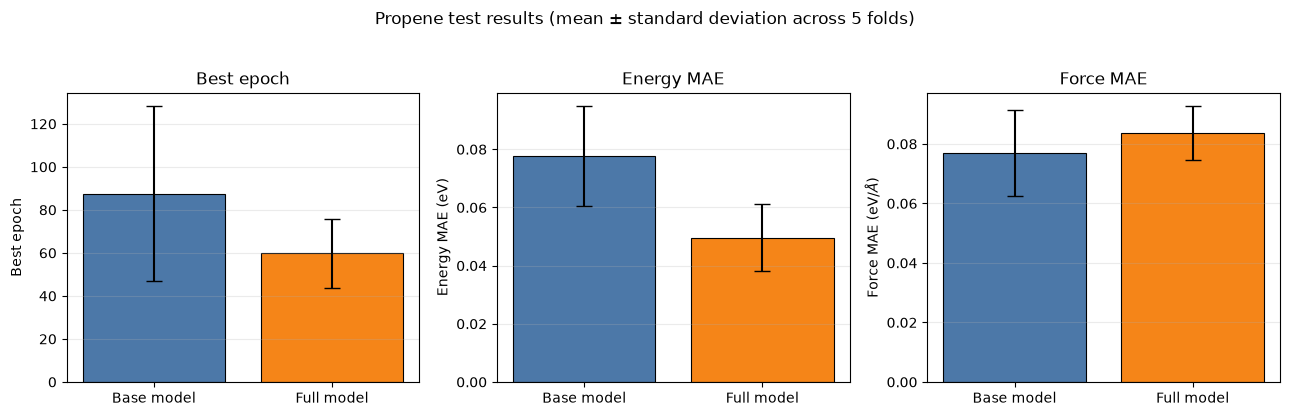

In [ ]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Path relative to scripts/output, or an absolute path to a result JSON file.
RESULT_FILE = Path("run_10/result.json")

# This works whether the kernel starts in the repository root or notebooks/.
if RESULT_FILE.is_absolute():
    result_candidates = [RESULT_FILE]
else:
    result_candidates = [
        Path("scripts/output") / RESULT_FILE,
        Path("../scripts/output") / RESULT_FILE,
    ]
result_path = next((path.resolve() for path in result_candidates if path.is_file()), None)
if result_path is None:
    raise FileNotFoundError(
        f"Could not find {RESULT_FILE} beneath scripts/output from the current directory."
    )

with result_path.open() as file:
    result = json.load(file)

training = result["cross_validation_training"]
model_groups = {
    "Base model": "base_models",
    "Full model": "full_high_fidelity_models",
}

def natural_sort_key(value):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", value)]


records = []
for model_label, group_key in model_groups.items():
    folds = training[group_key]["folds"]
    if not folds:
        raise ValueError(f"No folds found for {model_label}")

    for fold_key in sorted(folds, key=natural_sort_key):
        metrics = folds[fold_key]["metrics"]
        records.append(
            {
                "model": model_label,
                "fold": fold_key,
                "best_epoch": metrics["best_epoch"],
                "energy_mae_ev": metrics["energy_mae_ev"],
                "force_mae_ev_per_ang": metrics["force_mae_ev_per_ang"],
            }
        )

fold_data = pd.DataFrame(records)
metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
grouped = fold_data.groupby("model", sort=False)[metric_columns]
summary = grouped.agg(["mean", "std"])
fold_counts = fold_data.groupby("model", sort=False).size()

print(f"Loaded data from: {result_path}")
print("Fold counts:", fold_counts.to_dict())
print("\nFold-level data:")
print(fold_data.to_string(index=False))
print("\nMean and sample standard deviation across folds:")
print(summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
model_order = list(model_groups)
colors = ["#4C78A8", "#F58518"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (column, title, ylabel) in zip(axes, plot_specs):
    means = summary.loc[model_order, (column, "mean")].to_numpy()
    # A single fold has no sample standard deviation, so display a zero error bar.
    stds = summary.loc[model_order, (column, "std")].fillna(0).to_numpy()
    x = np.arange(len(model_order))

    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_xticks(x, model_order)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fold_description = ", ".join(
    f"{model}: {count} fold{'s' if count != 1 else ''}"
    for model, count in fold_counts.items()
)
fig.suptitle(
    f"Propene test results (mean ± standard deviation across 5 folds)\n"
)
fig.tight_layout()
plt.show()


# Butene

     model  fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base model     1         148       0.053135              0.061814
Base model     2          42       0.080003              0.099636
Base model     3         104       0.090429              0.068583
Base model     4          66       0.068785              0.075576
Base model     5          78       0.095689              0.079005
Full model     1          10       1.217875              0.709762
Full model     2           2       1.440978              0.852747
Full model     3           2       1.841792              1.256802
Full model     4          16       0.615367              0.556463
Full model     5          12       0.913333              0.760313

Mean and standard deviation across folds:
           best_epoch            energy_mae_ev           force_mae_ev_per_ang          
                 mean        std          mean       std                 mean       std
model                                                  

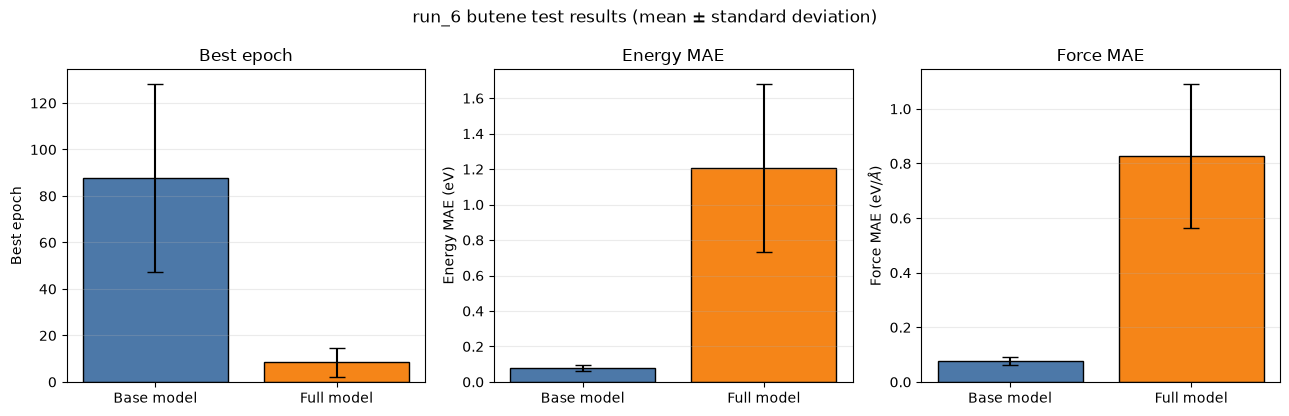

In [ ]:
import gc
import json
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from scripts.tester import _evaluate, _import_project_modules, _load_model

get_ipython().run_line_magic("matplotlib", "inline")

run_dir = Path("/home/yutong/X-MACE-sampling/scripts/output/run_6")
base_xyz = Path("/home/yutong/X-MACE-sampling/data/A03_butene_offgrid_128_sobol_2e2o.xyz")
full_xyz = Path("/home/yutong/X-MACE-sampling/data/A03_butene_offgrid_SA3-NEVPT2-22_molcas.xyz")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

result = json.loads((run_dir / "result.json").read_text())
config = result["config"]
modules = _import_project_modules()
Builder, Tester = modules[1], modules[2]
builder = Builder(
    cutoff=config.get("r_max", 5.0),
    energy_key=config.get("energy_key", "REF_energy"),
    forces_key=config.get("forces_key", "REF_forces"),
)
batch_size = config.get("batch_size", 64)
loaders = {
    "Base model": builder.load(ase.io.read(base_xyz, index=":"), batch_size=batch_size, shuffle=False),
    "Full model": builder.load(ase.io.read(full_xyz, index=":"), batch_size=batch_size, shuffle=False),
}
model_groups = {
    "Base model": ("base_model_fold_*.pt", "base_models"),
    "Full model": ("full_model_fold_*.pt", "full_high_fidelity_models"),
}

rows = []
for label, (pattern, group) in model_groups.items():
    for path in sorted(run_dir.glob(pattern), key=lambda p: int(p.stem.rsplit("_", 1)[1])):
        fold = int(path.stem.rsplit("_", 1)[1])
        model = _load_model(path, device)
        metrics = _evaluate(model, loaders[label], Tester(device=device))
        rows.append({
            "model": label,
            "fold": fold,
            "best_epoch": result["cross_validation_training"][group]["folds"][f"model_{fold}"]["metrics"]["best_epoch"],
            **metrics,
        })
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


In [ ]:

run_6_data = pd.DataFrame(rows)
metrics = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
run_6_summary = run_6_data.groupby("model", sort=False)[metrics].agg(["mean", "std"])
print(run_6_data.to_string(index=False))
print("\nMean and standard deviation across folds:")
print(run_6_summary.to_string())

specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
order = list(model_groups)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (metric, title, ylabel) in zip(axes, specs):
    means = run_6_summary.loc[order, (metric, "mean")]
    stds = run_6_summary.loc[order, (metric, "std")].fillna(0)
    bars = ax.bar(order, means, yerr=stds, capsize=6, color=["#4C78A8", "#F58518"], edgecolor="black")
    #ax.bar_label(bars, fmt="%.4g", padding=3)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Butene test results (mean ± standard deviation across 5 folds)")
fig.tight_layout()
plt.show()


# Ethene

In [3]:
import gc
import json
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from scripts.tester import _evaluate, _import_project_modules, _load_model

get_ipython().run_line_magic("matplotlib", "inline")

run_dir = Path("/home/yutong/X-MACE-sampling/scripts/output/run_4")
base_xyz = Path("/home/yutong/X-MACE-sampling/data/A01_ethene_offgrid_128_sobol_2e2o.xyz")
full_xyz = Path("/home/yutong/X-MACE-sampling/data/A01_ethene_offgrid_SA3-NEVPT2-22_molcas.xyz")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

result = json.loads((run_dir / "result.json").read_text())
config = result["config"]
modules = _import_project_modules()
Builder, Tester = modules[1], modules[2]
builder = Builder(
    cutoff=config.get("r_max", 5.0),
    energy_key=config.get("energy_key", "REF_energy"),
    forces_key=config.get("forces_key", "REF_forces"),
)
batch_size = config.get("batch_size", 64)
loaders = {
    "Base model": builder.load(ase.io.read(base_xyz, index=":"), batch_size=batch_size, shuffle=False),
    "Full model": builder.load(ase.io.read(full_xyz, index=":"), batch_size=batch_size, shuffle=False),
}
model_groups = {
    "Base model": ("base_model_fold_*.pt", "base_models"),
    "Full model": ("full_model_fold_*.pt", "full_high_fidelity_models"),
}

rows = []
for label, (pattern, group) in model_groups.items():
    for path in sorted(run_dir.glob(pattern), key=lambda p: int(p.stem.rsplit("_", 1)[1])):
        fold = int(path.stem.rsplit("_", 1)[1])
        model = _load_model(path, device)
        metrics = _evaluate(model, loaders[label], Tester(device=device))
        rows.append({
            "model": label,
            "fold": fold,
            "best_epoch": result["cross_validation_training"][group]["folds"][f"model_{fold}"]["metrics"]["best_epoch"],
            **metrics,
        })
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


ModuleNotFoundError: No module named 'scripts.tester'

In [ ]:

run_4_data = pd.DataFrame(rows)
metrics = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
run_4_summary = run_4_data.groupby("model", sort=False)[metrics].agg(["mean", "std"])
print(run_4_data.to_string(index=False))
print("\nMean and standard deviation across folds:")
print(run_4_summary.to_string())

specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
order = list(model_groups)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (metric, title, ylabel) in zip(axes, specs):
    means = run_4_summary.loc[order, (metric, "mean")]
    stds = run_4_summary.loc[order, (metric, "std")].fillna(0)
    bars = ax.bar(order, means, yerr=stds, capsize=6, color=["#4C78A8", "#F58518"], edgecolor="black")
    #ax.bar_label(bars, fmt="%.4g", padding=3)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Ethene test results (mean ± standard deviation across 5 folds)")
fig.tight_layout()
plt.show()

Run 8 transfer-model metrics:
  fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Fold 1         159       0.061295              0.170987
Fold 2         112       0.116704              0.175627
Fold 3         128       0.149406              0.170273
Fold 4         164       0.089401              0.160140
Fold 5         121       0.106830              0.176903

Mean and sample standard deviation across folds:
                            mean        std
best_epoch            136.800000  23.317375
energy_mae_ev           0.104727   0.032655
force_mae_ev_per_ang    0.170786   0.006605


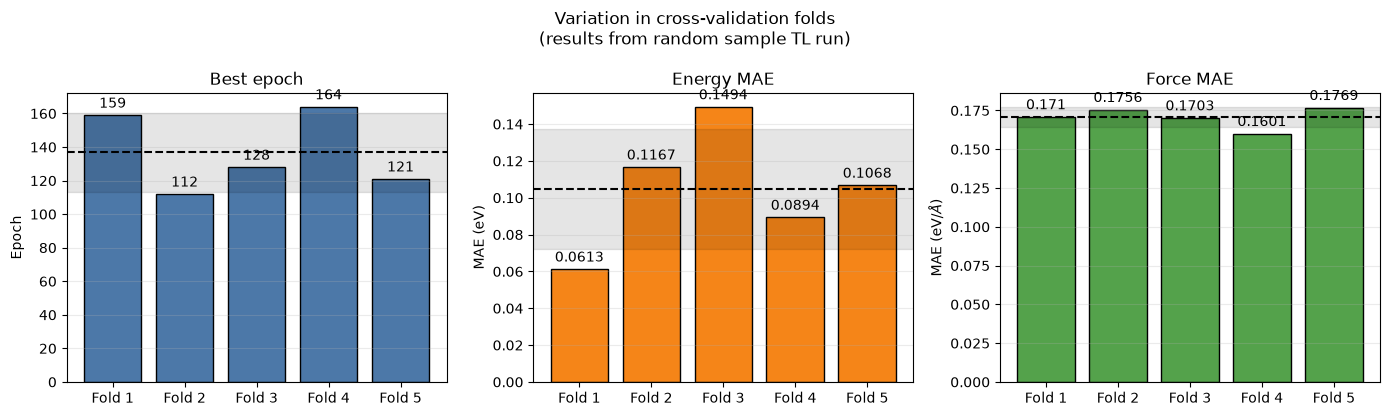

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

result_file = Path("/home/yutong/X-MACE-sampling/scripts/output/run_8/result.json")
result = json.loads(result_file.read_text())
folds = result["cross_validation_training"]["transfer_models"]["folds"]

run_8_data = pd.DataFrame(
    [
        {
            "fold": fold_name.replace("model_", "Fold "),
            "best_epoch": fold["metrics"]["best_epoch"],
            "energy_mae_ev": fold["metrics"]["energy_mae_ev"],
            "force_mae_ev_per_ang": fold["metrics"]["force_mae_ev_per_ang"],
        }
        for fold_name, fold in folds.items()
    ]
)

metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
run_8_summary = run_8_data[metric_columns].agg(["mean", "std"]).T

print("Run 8 transfer-model metrics:")
print(run_8_data.to_string(index=False))
print("\nMean and sample standard deviation across folds:")
print(run_8_summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Epoch"),
    ("energy_mae_ev", "Energy MAE", "MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"MAE (eV/$\AA$)"),
]
colors = ["#4C78A8", "#F58518", "#54A24B"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, (column, title, ylabel), color in zip(axes, plot_specs, colors):
    bars = ax.bar(run_8_data["fold"], run_8_data[column], color=color, edgecolor="black")
    mean = run_8_summary.loc[column, "mean"]
    std = run_8_summary.loc[column, "std"]
    ax.axhline(mean, color="black", linestyle="--", label=f"Mean = {mean:.4g}")
    ax.axhspan(mean - std, mean + std, color="black", alpha=0.10, label=f"Mean ± SD ({std:.4g})")
    ax.bar_label(bars, fmt="%.4g", padding=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    #ax.legend(fontsize=8)

fig.suptitle("Variation in cross-validation folds\n(results from random sample TL run)")
fig.tight_layout()
#plt.savefig("folds")
plt.show()


Fold-level data:
                            model    fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
        Base (low fidelity) model model_1          94       0.062199              0.102879
        Base (low fidelity) model model_2         172       0.053873              0.078630
        Base (low fidelity) model model_3          83       0.078716              0.105692
        Base (low fidelity) model model_4          98       0.068117              0.101611
        Base (low fidelity) model model_5          79       0.061028              0.118899
       Full (high fidelity) model model_1          95       0.070583              0.123894
       Full (high fidelity) model model_2          40       0.077190              0.179322
       Full (high fidelity) model model_3          64       0.123024              0.161210
       Full (high fidelity) model model_4          84       0.083550              0.127108
       Full (high fidelity) model model_5         119       0.069767     

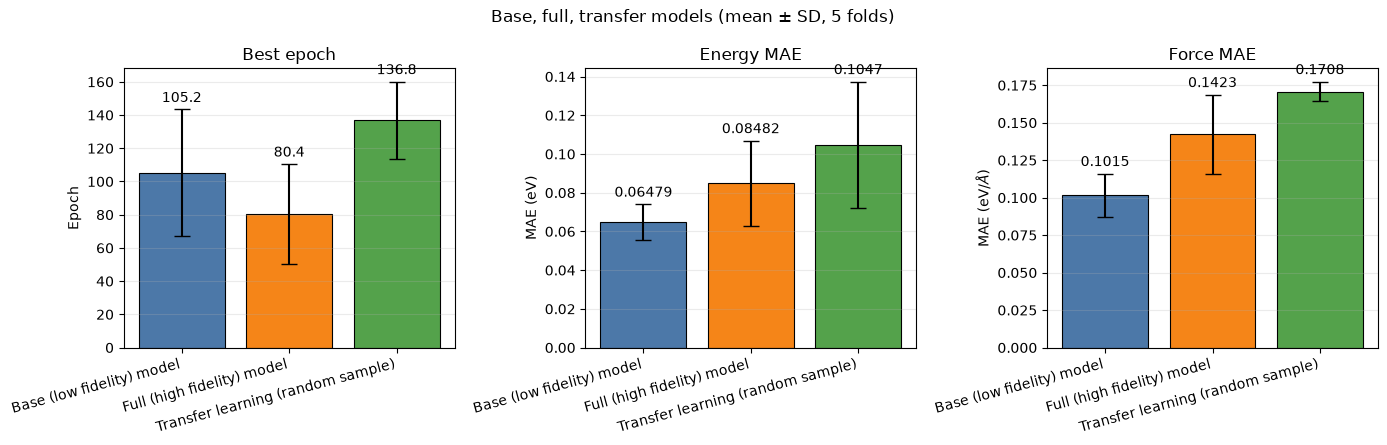

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

run_5 = json.loads(Path("/home/yutong/X-MACE-sampling/scripts/output/run_5/result.json").read_text())
run_8 = json.loads(Path("/home/yutong/X-MACE-sampling/scripts/output/run_8/result.json").read_text())

model_groups = [
    ("Base (low fidelity) model", run_5, "base_models"),
    ("Full (high fidelity) model", run_5, "full_high_fidelity_models"),
    ("Transfer learning (random sample)", run_8, "transfer_models"),
]

rows = []
for label, result, group in model_groups:
    folds = result["cross_validation_training"][group]["folds"]
    for fold_name, fold in folds.items():
        metrics = fold["metrics"]
        rows.append(
            {
                "model": label,
                "fold": fold_name,
                "best_epoch": metrics["best_epoch"],
                "energy_mae_ev": metrics["energy_mae_ev"],
                "force_mae_ev_per_ang": metrics["force_mae_ev_per_ang"],
            }
        )

comparison_data = pd.DataFrame(rows)
metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
model_order = [label for label, _, _ in model_groups]
comparison_summary = (
    comparison_data.groupby("model", sort=False)[metric_columns]
    .agg(["mean", "std"])
    .loc[model_order]
)

print("Fold-level data:")
print(comparison_data.to_string(index=False))
print("\nMean and sample standard deviation across five folds:")
print(comparison_summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Epoch"),
    ("energy_mae_ev", "Energy MAE", "MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"MAE (eV/$\AA$)"),
]
colors = ["#4C78A8", "#F58518", "#54A24B"]
x = np.arange(len(model_order))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    means = comparison_summary[(metric, "mean")].to_numpy()
    stds = comparison_summary[(metric, "std")].to_numpy()
    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.bar_label(bars, labels=[f"{mean:.4g}" for mean in means], padding=3)
    ax.set_xticks(x, model_order, rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Base, full, transfer models (mean ± SD, 5 folds)")
fig.tight_layout()
#plt.savefig("base full transfer")
plt.show()


Fold-level data:
                  model    fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base without foundation model_1          94       0.062199              0.102879
Base without foundation model_2         172       0.053873              0.078630
Base without foundation model_3          83       0.078716              0.105692
Base without foundation model_4          98       0.068117              0.101611
Base without foundation model_5          79       0.061028              0.118899
Full without foundation model_1          95       0.070583              0.123894
Full without foundation model_2          40       0.077190              0.179322
Full without foundation model_3          64       0.123024              0.161210
Full without foundation model_4          84       0.083550              0.127108
Full without foundation model_5         119       0.069767              0.120178
   Base with foundation model_1          74       0.073374              0.088402
   Base wit

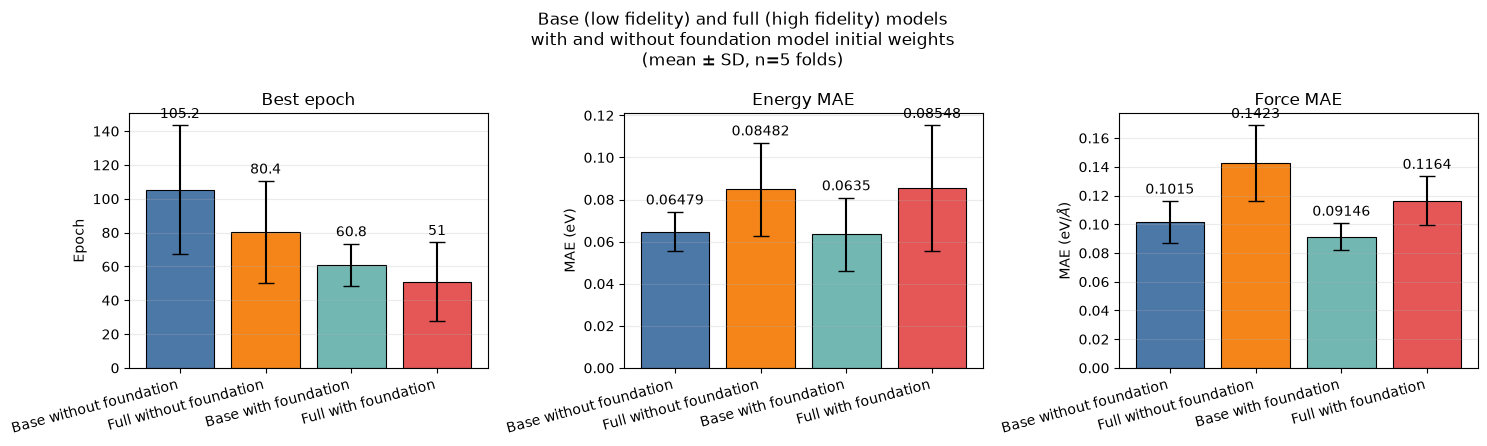

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

run_5 = json.loads(Path("/home/yutong/X-MACE-sampling/scripts/output/run_5/result.json").read_text())
run_7 = json.loads(Path("/home/yutong/X-MACE-sampling/scripts/output/run_7/result.json").read_text())

model_groups = [
    ("Base without foundation", run_5, "base_models"),
    ("Full without foundation", run_5, "full_high_fidelity_models"),
    ("Base with foundation", run_7, "base_models"),
    ("Full with foundation", run_7, "full_high_fidelity_models"),
]

rows = []
for label, result, group in model_groups:
    folds = result["cross_validation_training"][group]["folds"]
    for fold_name, fold in folds.items():
        metrics = fold["metrics"]
        rows.append(
            {
                "model": label,
                "fold": fold_name,
                "best_epoch": metrics["best_epoch"],
                "energy_mae_ev": metrics["energy_mae_ev"],
                "force_mae_ev_per_ang": metrics["force_mae_ev_per_ang"],
            }
        )

run_5_7_data = pd.DataFrame(rows)
metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
model_order = [label for label, _, _ in model_groups]
run_5_7_summary = (
    run_5_7_data.groupby("model", sort=False)[metric_columns]
    .agg(["mean", "std"])
    .loc[model_order]
)

print("Fold-level data:")
print(run_5_7_data.to_string(index=False))
print("\nMean and sample standard deviation across five folds:")
print(run_5_7_summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Epoch"),
    ("energy_mae_ev", "Energy MAE", "MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"MAE (eV/$\AA$)"),
]
colors = ["#4C78A8", "#F58518", "#72B7B2", "#E45756"]
x = np.arange(len(model_order))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    means = run_5_7_summary[(metric, "mean")].to_numpy()
    stds = run_5_7_summary[(metric, "std")].to_numpy()
    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.bar_label(bars, labels=[f"{mean:.4g}" for mean in means], padding=3)
    ax.set_xticks(x, model_order, rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Base (low fidelity) and full (high fidelity) models\nwith and without foundation model initial weights\n(mean ± SD, n=5 folds)")
fig.tight_layout()
#plt.savefig('with without foundation')
plt.show()


Fold-level data:
                  model    fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base without foundation model_1          34       3.132678              1.667801
Base without foundation model_2          36       3.127787              1.633922
Base without foundation model_3          46       3.019054              1.515003
Base without foundation model_4         120       3.106628              1.599954
Base without foundation model_5          32       3.149357              1.601748
Full without foundation model_1          28       3.771283              1.954616
Full without foundation model_2          33       3.869804              1.960633
Full without foundation model_3          32       3.800997              1.869672
Full without foundation model_4          33       3.959113              1.946048
Full without foundation model_5          33       3.933266              1.981900
   Base with foundation model_1          33       0.107911              0.101359
   Base wit

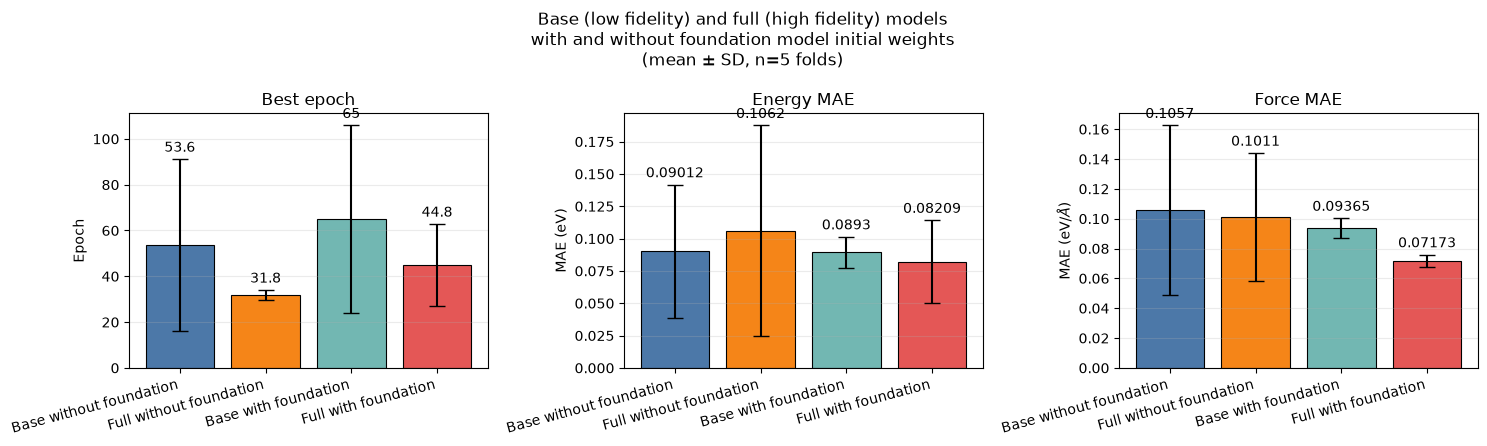

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

run_4 = json.loads(Path("/home/lim_yt/X-MACE-sampling/scripts/output/run_4/result.json").read_text())
run_9 = json.loads(Path("/home/lim_yt/X-MACE-sampling/scripts/output/run_9/result.json").read_text())
model_groups = [
    ("Base without foundation", run_4, "base_models"),
    ("Full without foundation", run_4, "full_high_fidelity_models"),
    ("Base with foundation", run_9, "base_models"),
    ("Full with foundation", run_9, "full_high_fidelity_models"),
]

rows = []
for label, result, group in model_groups:
    folds = result["cross_validation_training"][group]["folds"]
    for fold_name, fold in folds.items():
        metrics = fold["metrics"]
        rows.append(
            {
                "model": label,
                "fold": fold_name,
                "best_epoch": metrics["best_epoch"],
                "energy_mae_ev": metrics["energy_mae_ev"],
                "force_mae_ev_per_ang": metrics["force_mae_ev_per_ang"],
            }
        )

run_4_9_data = pd.DataFrame(rows)
metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
model_order = [label for label, _, _ in model_groups]
run_4_9_summary = (
    run_4_9_data.groupby("model", sort=False)[metric_columns]
    .agg(["mean", "std"])
    .loc[model_order]
)

print("Fold-level data:")
print(run_4_9_data.to_string(index=False))
print("\nMean and sample standard deviation across five folds:")
print(run_4_9_summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Epoch"),
    ("energy_mae_ev", "Energy MAE", "MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"MAE (eV/$\AA$)"),
]
colors = ["#4C78A8", "#F58518", "#72B7B2", "#E45756"]
x = np.arange(len(model_order))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    means = run_4_9_summary[(metric, "mean")].to_numpy()
    stds = run_4_9_summary[(metric, "std")].to_numpy()
    if title == 'Energy MAE':
        means = [0.090122, 0.106249, 0.089303, 0.082085]
        std = [0.011569, 0.020293, 0.012024, 0.032007]
    if title == 'Force MAE':
        means = [0.105665, 0.101055, 0.093645, 0.071730]
        std = [0.013746, 0.006546, 0.006588, 0.004087]
    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.bar_label(bars, labels=[f"{mean:.4g}" for mean in means], padding=3)
    ax.set_xticks(x, model_order, rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Base (low fidelity) and full (high fidelity) models\nwith and without foundation model initial weights\n(mean ± SD, n=5 folds)")
fig.tight_layout()
#plt.savefig('with without foundation')
plt.show()


## Transfer-learning sampling comparison

The error bars are the standard deviations across the five transfer-model cross-validation folds.

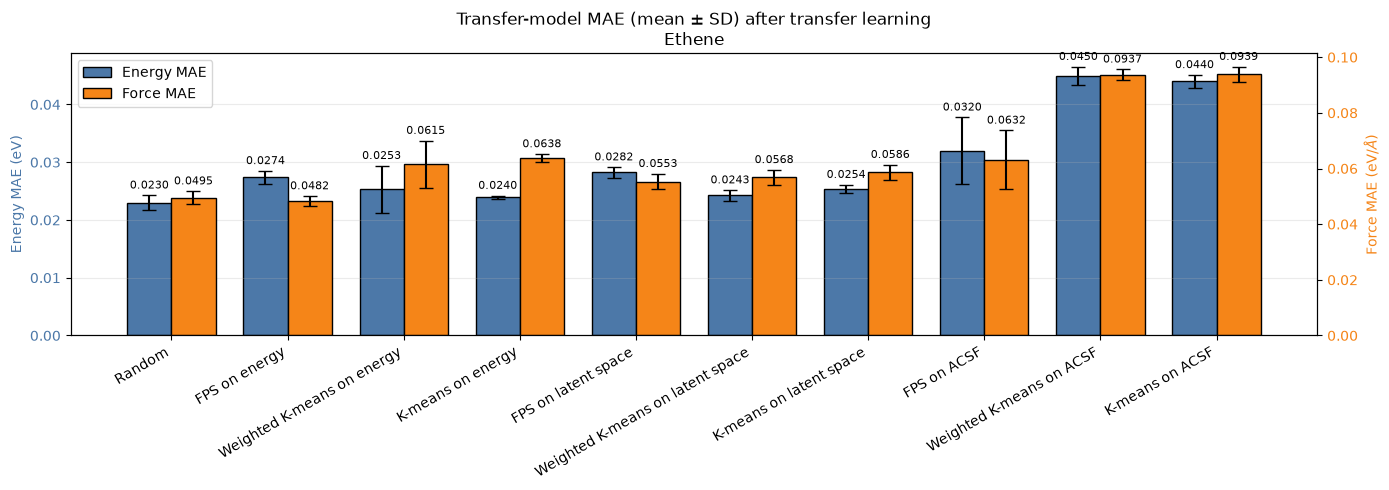

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUNS = range(39, 49)

# This works whether the notebook is run from the repository root or notebooks/.
output_root = next(
    (path for path in (Path("scripts/output"), Path("../scripts/output")) if path.is_dir()),
    None,
)
input_root = next(
    (path for path in (Path("scripts/input"), Path("../scripts/input")) if path.is_dir()),
    None,
)
if output_root is None or input_root is None:
    raise FileNotFoundError("Run outputs or input configurations could not be found.")

selector_labels = {
    "random_sampling": "Random",
    "farthest_point_sampling": "FPS",
    "k_means_clustering_weighted": "Weighted K-means",
    "k_means_clustering": "K-means",
}
descriptor_labels = {
    "energies": "energy",
    "latent_space": "latent space",
    "acsf": "ACSF",
}

records = []
for run in RUNS:
    with (output_root / f"run_{run}" / "result.json").open() as file:
        result = json.load(file)

    # Use the input filename stored in the result rather than relying on absolute paths.
    input_path = input_root / Path(result["input_file"]).name
    with input_path.open() as file:
        config = json.load(file)

    selector = selector_labels[config["selector"]]
    label = selector if selector == "Random" else f"{selector} on {descriptor_labels[config['descriptor']]}"
    metrics = result["metrics"]["transfer_models"]
    records.append({
        "run": run,
        "label": label,
        "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
        "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
        "energy_mean": metrics["energy_mae_ev"]["mean"],
        "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
    })

# Keep the random baseline at the left of both plots.
records.sort(key=lambda record: record["label"] != "Random")

def plot_maes(records, molecule):
    labels = [record["label"] for record in records]
    energy_means = [record["energy_mean"] for record in records]
    energy_stds = [record["energy_std"] for record in records]
    force_means = [record["force_mean"] for record in records]
    force_stds = [record["force_std"] for record in records]
    x = np.arange(len(records))
    width = 0.38

    fig, energy_ax = plt.subplots(figsize=(14, 5))
    force_ax = energy_ax.twinx()
    energy_bars = energy_ax.bar(
        x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
        edgecolor="black", color="#4C78A8", label="Energy MAE"
    )
    force_bars = force_ax.bar(
        x + width / 2, force_means, width, yerr=force_stds, capsize=5,
        edgecolor="black", color="#F58518", label="Force MAE"
    )
    energy_ax.bar_label(energy_bars, labels=[f"{mean:.4f}" for mean in energy_means], padding=3, fontsize=8)
    force_ax.bar_label(force_bars, labels=[f"{mean:.4f}" for mean in force_means], padding=3, fontsize=8)
    energy_ax.set_xticks(x, labels, rotation=30, ha="right")
    energy_ax.set_title(f"Transfer-model MAE (mean ± SD) after transfer learning\n{molecule}")
    energy_ax.set_ylabel("Energy MAE (eV)", color="#4C78A8")
    force_ax.set_ylabel(r"Force MAE (eV/$\AA$)", color="#F58518")
    energy_ax.tick_params(axis="y", labelcolor="#4C78A8")
    force_ax.tick_params(axis="y", labelcolor="#F58518")
    energy_ax.grid(axis="y", alpha=0.25)
    energy_ax.legend(handles=[energy_bars, force_bars], loc="upper left")
    fig.tight_layout()
    plt.show()

plot_maes(records, "Ethene")


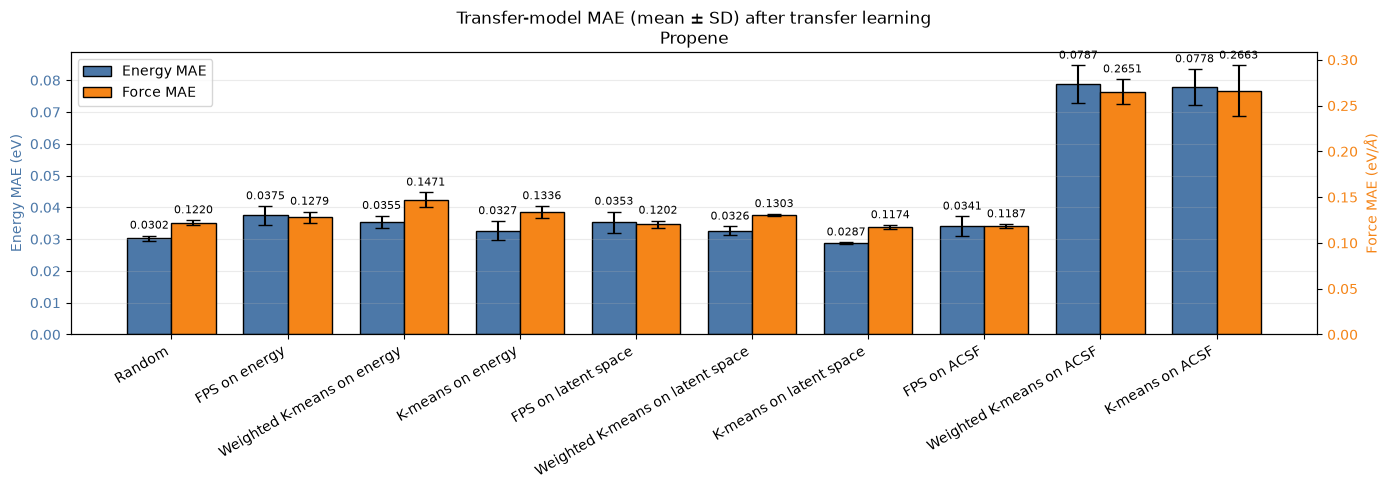

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUNS = [*range(49, 58), 67]

output_root = next(
    (path for path in (Path("scripts/output"), Path("../scripts/output")) if path.is_dir()),
    None,
)
input_root = next(
    (path for path in (Path("scripts/input"), Path("../scripts/input")) if path.is_dir()),
    None,
)
if output_root is None or input_root is None:
    raise FileNotFoundError("Run outputs or input configurations could not be found.")

selector_labels = {
    "random_sampling": "Random",
    "farthest_point_sampling": "FPS",
    "k_means_clustering_weighted": "Weighted K-means",
    "k_means_clustering": "K-means",
}
descriptor_labels = {
    "energies": "energy",
    "latent_space": "latent space",
    "acsf": "ACSF",
}

records = []
for run in RUNS:
    with (output_root / f"run_{run}" / "result.json").open() as file:
        result = json.load(file)

    input_path = input_root / Path(result["input_file"]).name
    with input_path.open() as file:
        config = json.load(file)

    selector = selector_labels[config["selector"]]
    label = selector if selector == "Random" else f"{selector} on {descriptor_labels[config['descriptor']]}"
    metrics = result["metrics"]["transfer_models"]
    records.append({
        "run": run,
        "label": label,
        "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
        "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
        "energy_mean": metrics["energy_mae_ev"]["mean"],
        "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
    })

# Keep the random baseline at the left of both plots.
records.sort(key=lambda record: record["label"] != "Random")

def plot_maes(records, molecule):
    labels = [record["label"] for record in records]
    energy_means = [record["energy_mean"] for record in records]
    energy_stds = [record["energy_std"] for record in records]
    force_means = [record["force_mean"] for record in records]
    force_stds = [record["force_std"] for record in records]
    x = np.arange(len(records))
    width = 0.38

    fig, energy_ax = plt.subplots(figsize=(14, 5))
    force_ax = energy_ax.twinx()
    energy_bars = energy_ax.bar(
        x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
        edgecolor="black", color="#4C78A8", label="Energy MAE"
    )
    force_bars = force_ax.bar(
        x + width / 2, force_means, width, yerr=force_stds, capsize=5,
        edgecolor="black", color="#F58518", label="Force MAE"
    )
    energy_ax.bar_label(energy_bars, labels=[f"{mean:.4f}" for mean in energy_means], padding=3, fontsize=8)
    force_ax.bar_label(force_bars, labels=[f"{mean:.4f}" for mean in force_means], padding=3, fontsize=8)
    energy_ax.set_xticks(x, labels, rotation=30, ha="right")
    energy_ax.set_title(f"Transfer-model MAE (mean ± SD) after transfer learning\n{molecule}")
    energy_ax.set_ylabel("Energy MAE (eV)", color="#4C78A8")
    force_ax.set_ylabel(r"Force MAE (eV/$\AA$)", color="#F58518")
    energy_ax.tick_params(axis="y", labelcolor="#4C78A8")
    force_ax.tick_params(axis="y", labelcolor="#F58518")
    energy_ax.grid(axis="y", alpha=0.25)
    energy_ax.legend(handles=[energy_bars, force_bars], loc="upper left")
    fig.tight_layout()
    plt.show()

plot_maes(records, "Propene")


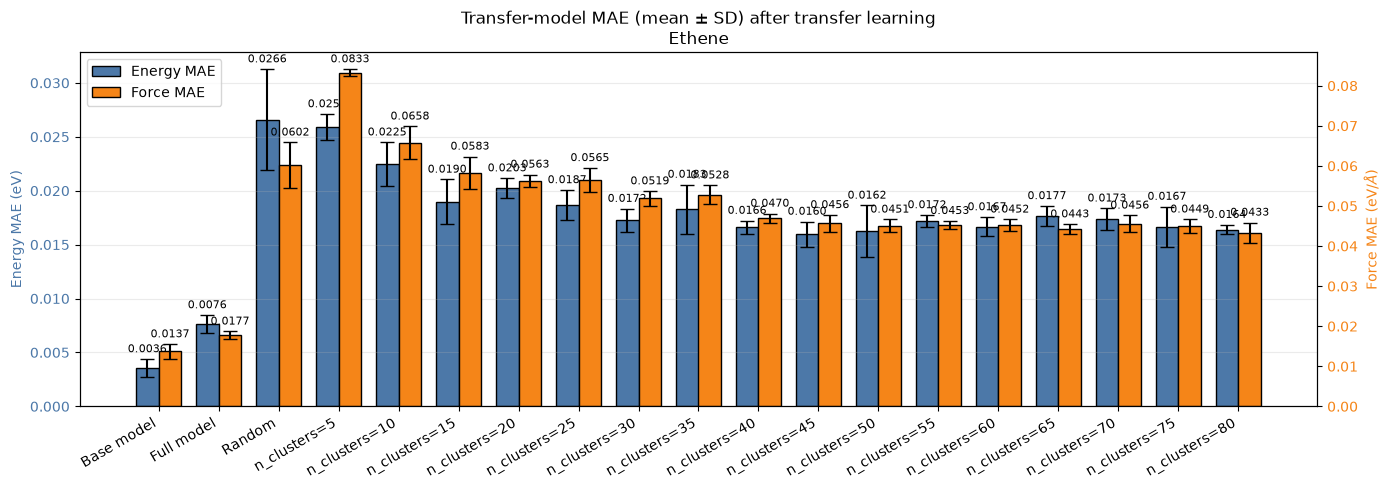

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUNS = [*range(13, 21), *range(22, 30)]

output_root = next(
    (path for path in (Path("scripts/output"), Path("../scripts/output")) if path.is_dir()),
    None,
)
if output_root is None:
    raise FileNotFoundError("Run outputs could not be found.")

# Load the independently cross-validated base and full models from run 2.
with (output_root / "run_2" / "result.json").open() as file:
    run_2_result = json.load(file)

records = []

for label, model_key in (
    ("Base model", "base_models"),
    ("Full model", "full_high_fidelity_models"),
):
    metrics = run_2_result["metrics"][model_key]
    records.append({
        "run": 2,
        "label": label,
        "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
        "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
        "energy_mean": metrics["energy_mae_ev"]["mean"],
        "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
    })

# Include the random-sampling transfer model from run 3.
with (output_root / "run_3" / "result.json").open() as file:
    run_3_result = json.load(file)

metrics = run_3_result["metrics"]["transfer_models"]
records.append({
    "run": 3,
    "label": "Random",
    "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
    "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
    "energy_mean": metrics["energy_mae_ev"]["mean"],
    "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
})

for run in RUNS:
    with (output_root / f"run_{run}" / "result.json").open() as file:
        result = json.load(file)

    n_clusters = result["config"]["selector_kwargs"]["n_clusters"]
    label = f"n_clusters={n_clusters}"
    metrics = result["metrics"]["transfer_models"]
    records.append({
        "run": run,
        "label": label,
        "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
        "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
        "energy_mean": metrics["energy_mae_ev"]["mean"],
        "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
    })

def plot_maes(records, molecule):
    labels = [record["label"] for record in records]
    energy_means = [record["energy_mean"] for record in records]
    energy_stds = [record["energy_std"] for record in records]
    force_means = [record["force_mean"] for record in records]
    force_stds = [record["force_std"] for record in records]
    x = np.arange(len(records))
    width = 0.38

    fig, energy_ax = plt.subplots(figsize=(14, 5))
    force_ax = energy_ax.twinx()
    energy_bars = energy_ax.bar(
        x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
        edgecolor="black", color="#4C78A8", label="Energy MAE"
    )
    force_bars = force_ax.bar(
        x + width / 2, force_means, width, yerr=force_stds, capsize=5,
        edgecolor="black", color="#F58518", label="Force MAE"
    )
    energy_ax.bar_label(energy_bars, labels=[f"{mean:.4f}" for mean in energy_means], padding=3, fontsize=8)
    force_ax.bar_label(force_bars, labels=[f"{mean:.4f}" for mean in force_means], padding=3, fontsize=8)
    energy_ax.set_xticks(x, labels, rotation=30, ha="right")
    energy_ax.set_title(f"Transfer-model MAE (mean ± SD) after transfer learning\n{molecule}")
    energy_ax.set_ylabel("Energy MAE (eV)", color="#4C78A8")
    force_ax.set_ylabel(r"Force MAE (eV/$\AA$)", color="#F58518")
    energy_ax.tick_params(axis="y", labelcolor="#4C78A8")
    force_ax.tick_params(axis="y", labelcolor="#F58518")
    energy_ax.grid(axis="y", alpha=0.25)
    energy_ax.legend(handles=[energy_bars, force_bars], loc="upper left")
    fig.tight_layout()
    plt.show()

plot_maes(records, "Ethene")


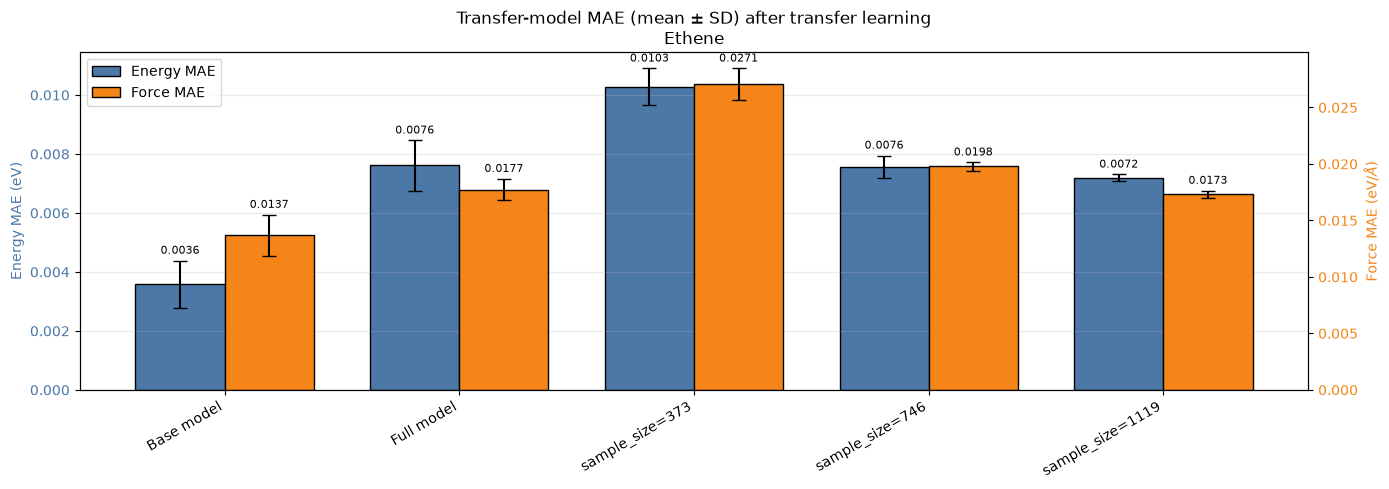

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUNS = [*range(71,74)]

output_root = next(
    (path for path in (Path("scripts/output"), Path("../scripts/output")) if path.is_dir()),
    None,
)
if output_root is None:
    raise FileNotFoundError("Run outputs could not be found.")

# Load the independently cross-validated base and full models from run 2.
with (output_root / "run_2" / "result.json").open() as file:
    run_2_result = json.load(file)

records = []

for label, model_key in (
    ("Base model", "base_models"),
    ("Full model", "full_high_fidelity_models"),
):
    metrics = run_2_result["metrics"][model_key]
    records.append({
        "run": 2,
        "label": label,
        "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
        "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
        "energy_mean": metrics["energy_mae_ev"]["mean"],
        "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
    })

for run in RUNS:
    with (output_root / f"run_{run}" / "result.json").open() as file:
        result = json.load(file)

    sample_size = result["config"]["n_samples"]
    label = f"sample_size={sample_size}"
    metrics = result["metrics"]["transfer_models"]
    records.append({
        "run": run,
        "label": label,
        "force_mean": metrics["force_mae_ev_per_ang"]["mean"],
        "force_std": np.sqrt(metrics["force_mae_ev_per_ang"]["variance"]),
        "energy_mean": metrics["energy_mae_ev"]["mean"],
        "energy_std": np.sqrt(metrics["energy_mae_ev"]["variance"]),
    })

def plot_maes(records, molecule):
    labels = [record["label"] for record in records]
    energy_means = [record["energy_mean"] for record in records]
    energy_stds = [record["energy_std"] for record in records]
    force_means = [record["force_mean"] for record in records]
    force_stds = [record["force_std"] for record in records]
    x = np.arange(len(records))
    width = 0.38

    fig, energy_ax = plt.subplots(figsize=(14, 5))
    force_ax = energy_ax.twinx()
    energy_bars = energy_ax.bar(
        x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
        edgecolor="black", color="#4C78A8", label="Energy MAE"
    )
    force_bars = force_ax.bar(
        x + width / 2, force_means, width, yerr=force_stds, capsize=5,
        edgecolor="black", color="#F58518", label="Force MAE"
    )
    energy_ax.bar_label(energy_bars, labels=[f"{mean:.4f}" for mean in energy_means], padding=3, fontsize=8)
    force_ax.bar_label(force_bars, labels=[f"{mean:.4f}" for mean in force_means], padding=3, fontsize=8)
    energy_ax.set_xticks(x, labels, rotation=30, ha="right")
    energy_ax.set_title(f"Transfer-model MAE (mean ± SD) after transfer learning\n{molecule}")
    energy_ax.set_ylabel("Energy MAE (eV)", color="#4C78A8")
    force_ax.set_ylabel(r"Force MAE (eV/$\AA$)", color="#F58518")
    energy_ax.tick_params(axis="y", labelcolor="#4C78A8")
    force_ax.tick_params(axis="y", labelcolor="#F58518")
    energy_ax.grid(axis="y", alpha=0.25)
    energy_ax.legend(handles=[energy_bars, force_bars], loc="upper left")
    fig.tight_layout()
    plt.show()

plot_maes(records, "Ethene")
